# 1.2 Autoencoders

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import torchvision.transforms as transforms
# Device selection: GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

We will be using

- **Pytorch**. Since pytorch can use GPUs or TPUs if available, it is usually better to force all data types to be `np.float32` or `int`.

- The **MNIST** digits classification dataset. Observe how **we normalize** the MNIST images.

## 1. Load data

In [64]:
mnist = pd.read_csv("local/data/mnist1.5k.csv.gz", compression="gzip", header=None).values
X=(mnist[:,1:785]/255.).astype(np.float32)
y=(mnist[:,0]).astype(int)
print("dimension de las imagenes y las clases", X.shape, y.shape)

dimension de las imagenes y las clases (1500, 784) (1500,)


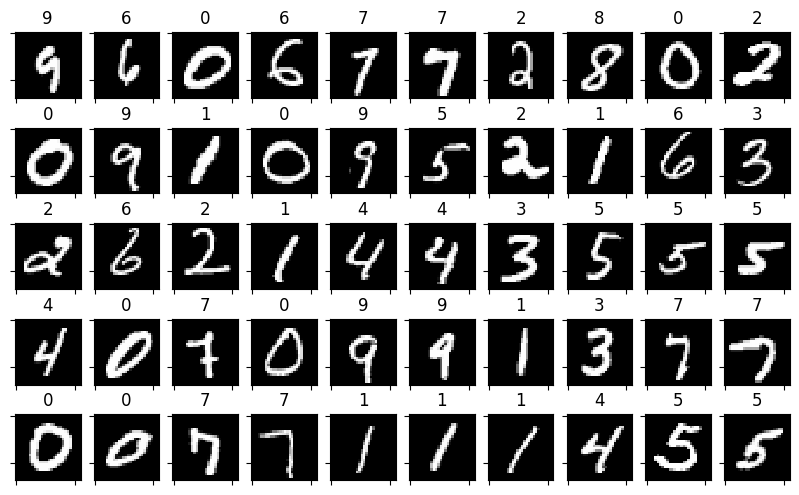

In [65]:
perm = np.random.permutation(list(range(X.shape[0])))[0:50]
random_imgs   = X[perm]
random_labels = y[perm]
fig = plt.figure(figsize=(10,6))
for i in range(random_imgs.shape[0]):
    ax=fig.add_subplot(5,10,i+1)
    plt.imshow(random_imgs[i].reshape(28,28), interpolation="nearest", cmap = plt.cm.Greys_r)
    ax.set_title(int(random_labels[i]))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

and we do the regular train/test split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1200, 784), (300, 784), (1200,), (300,))

## 2. Building the data loading pipeline


setup a dataloader from the data arrays. **Observe we need to convert arrays to tensors**

In [67]:
tX_train = torch.from_numpy(X_train)
ty_train = torch.from_numpy(y_train)

tX_test = torch.from_numpy(X_test)
ty_test = torch.from_numpy(y_test)
tX_train, ty_train

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([8, 8, 2,  ..., 0, 0, 6]))

In [68]:
train_dataset = TensorDataset(tX_train, ty_train)
test_dataset = TensorDataset(tX_test, ty_test)

train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,      # Good practice for training
    num_workers=0      # Increase if on Linux/Mac for faster loading
)

we can now loop over the data

In [7]:
for x,y in train_loader:
    break

In [8]:
x.shape, y.shape

(torch.Size([32, 784]), torch.Size([32]))

## 3. Assemble and train an autoencoder

Observe how an autoencoder is just a concatenation of two regular `Linear` layers. **Why are we using a sigmoid as decoder output activation?**

In [87]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import lightning as L

class Autoencoder(L.LightningModule):
    def __init__(self, input_size, code_size):
        super().__init__()
        
        self.encoder = nn.Linear(input_size, code_size)
        self.decoder = nn.Linear(code_size, input_size)

        self.loss_history = []

    def forward(self, x):
        x = self.encoder(x)
        x = F.relu(x)
        x = self.decoder(x)
        x = F.sigmoid(x)
        return x

    def training_step(self, batch, batch_idx):
        x, _ = batch
        o = self.forward(x)
        self.loss = torch.mean((o-x)**2)
        self.log("train_loss", self.loss, on_step=False, on_epoch=True)
        return self.loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=0.005),
        return optimizer

    def on_train_epoch_end(self):
        self.loss_history.append(self.loss.detach().numpy())


# Example instantiation
model = Autoencoder(input_size=X_train.shape[1], code_size=50)
summary(model)

Layer (type:depth-idx)                   Param #
Autoencoder                              --
├─Linear: 1-1                            39,250
├─Linear: 1-2                            39,984
Total params: 79,234
Trainable params: 79,234
Non-trainable params: 0

test we can do inference on the model (still not trained)

In [88]:
o = model(x)
x.shape, o.shape

(torch.Size([32, 784]), torch.Size([32, 784]))

In [89]:
torch.mean((o-x)**2)

tensor(0.2333, grad_fn=<MeanBackward0>)

the training loop.

This is **self supervised** actual digit class `y` is not needed

In [90]:
trainer = L.Trainer(max_epochs=40) # Configure the trainer
trainer.fit(model=model, train_dataloaders=train_loader) 


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name    | Type   | Params | Mode  | FLOPs
---------------------------------------------------
0 | encoder | Linear | 39.2 K | train | 0    
1 | decoder | Linear | 40.0 K | train | 0    
---------------------------------------------------
79.2 K    Trainable params
0         Non-trainable params
79.2 K    Total params
0.317     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode
0         Total Flops


Training: |                                                                                             | 0/? …

`Trainer.fit` stopped: `max_epochs=40` reached.


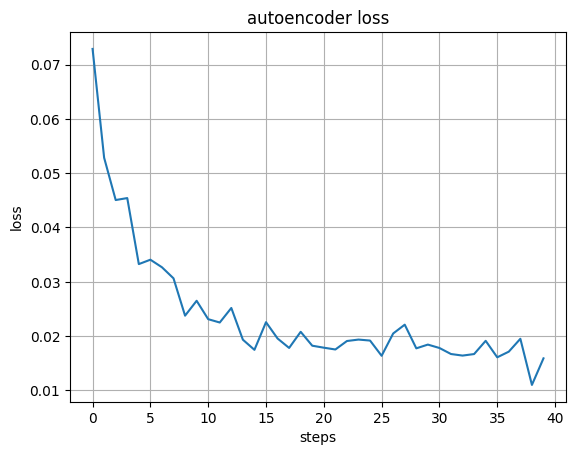

In [91]:
plt.plot(model.loss_history)
plt.grid()
plt.title('autoencoder loss')
plt.xlabel('steps')
plt.ylabel('loss')
plt.show()

The training seems to have gone well (the loss was reduced)

Question: How can we measure how good was the result?

You can try with larger layers, with more layers, etc.

## 4. Making predictions

We can feed the model any input and get the output. Observe we get eager tensors, which are like a symbolic wrapper to numpy matrices. We will see more about this later in this course.

In [92]:
o = model(tX_train)
o

tensor([[1.1708e-06, 2.3696e-05, 2.2554e-06,  ..., 6.1075e-06, 3.2354e-05,
         4.0329e-05],
        [1.5838e-08, 1.6519e-08, 2.8080e-08,  ..., 5.0094e-10, 2.5491e-08,
         2.4741e-07],
        [1.2079e-08, 1.4758e-08, 1.2914e-07,  ..., 1.4667e-09, 1.0404e-07,
         7.8154e-07],
        ...,
        [2.2008e-06, 2.9979e-04, 7.8546e-05,  ..., 1.1146e-06, 3.9752e-05,
         1.6441e-06],
        [7.0906e-09, 1.0792e-06, 3.8156e-06,  ..., 3.0981e-08, 1.6966e-06,
         5.7844e-06],
        [3.6701e-05, 8.9885e-05, 1.9870e-04,  ..., 7.6748e-05, 3.8365e-05,
         4.0526e-05]], grad_fn=<SigmoidBackward0>)

This is an autoencoder, so hopefuly the prediction (the reconstruction) should be similar to the input

torch.Size([10, 784])


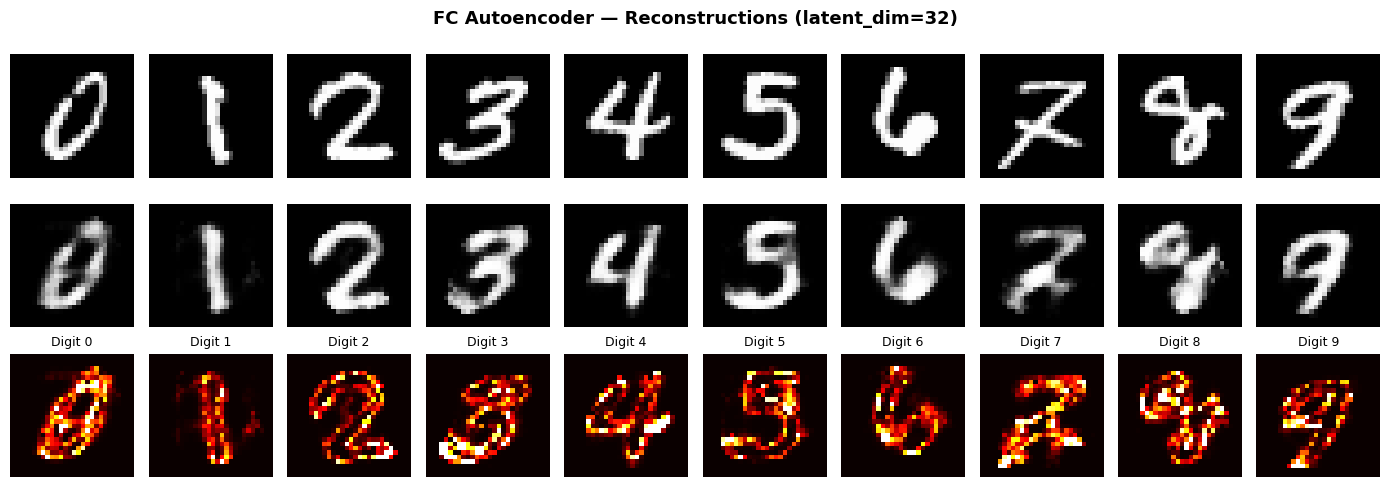

In [93]:
def show_reconstructions(model, data_loader, n=10, title='Reconstructions'):
    model.eval()
    # pick one sample per digit class
    indices = []
    for cls in range(n):
        idx = next(i for i, (_,y) in enumerate(data_loader) if  y== cls)
        indices.append(idx)

    imgs = torch.stack([data_loader[i][0] for i in indices]).to(device)
    print(imgs.shape)
    with torch.no_grad():
        recon = model(imgs)

    imgs   = imgs.cpu().numpy()
    recon  = recon.cpu().numpy()

    fig, axes = plt.subplots(3, n, figsize=(14, 5))
    for i in range(n):
        # Original
        axes[0, i].imshow(imgs[i].reshape(28,28), cmap='gray', vmin=0, vmax=1)
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_ylabel('Original', fontsize=10, fontweight='bold')

        # Reconstruction
        axes[1, i].imshow(recon[i].reshape(28,28), cmap='gray', vmin=0, vmax=1)
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_ylabel('Recon.', fontsize=10, fontweight='bold')

        # Difference map
        diff = np.abs(imgs[i].reshape(28,28) - recon[i].reshape(28,28))
        axes[2, i].imshow(diff, cmap='hot', vmin=0, vmax=0.5)
        axes[2, i].axis('off')
        if i == 0: axes[2, i].set_ylabel('|Error|', fontsize=10, fontweight='bold')
        axes[2, i].set_title(f'Digit {i}', fontsize=9)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_reconstructions(model, train_dataset, title='FC Autoencoder — Reconstructions (latent_dim=32)')

## 5. Exploring the Latent Space (Embeddings)

To visualize the learned embedding, we train a separate autoencoder with **latent_dim=2** — so we can plot the entire space on a 2D scatter plot.

If the autoencoder has learned meaningful structure, **digits of the same class should cluster together**, even though we never provided labels during training.

For this part we need more data.

In [40]:
# Normalize to [0, 1] — pixel values as reconstruction targets
transform = transforms.Compose([
    transforms.ToTensor(),  # scales to [0, 1]
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples : {len(train_dataset):,}")
print(f"Test samples     : {len(test_dataset):,}")
print(f"Image shape      : {train_dataset[0][0].shape}  →  flattened: 784 dims")


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████| 9912422/9912422 [00:02<00:00, 3512784.44it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|███████████████████████████████████████████████████████████████████████████████| 28881/28881 [00:00<00:00, 157420.28it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████| 1648877/1648877 [00:00<00:00, 3090463.34it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|████████████████████████████████████████████████████████████████████████████████| 4542/4542 [00:00<00:00, 2440498.18it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Training samples : 60,000
Test samples     : 10,000
Image shape      : torch.Size([1, 28, 28])  →  flattened: 784 dims


In [53]:
class Autoencoder2D(L.LightningModule):
    def __init__(self, input_size, code_size):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 10*code_size), nn.ReLU(),
            nn.Linear(10*code_size, code_size), # bottleneck — NO activation
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(code_size, 10*code_size), nn.ReLU(),
            nn.Linear(10*code_size,input_size),
        )

        self.loss_history = []

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = F.sigmoid(x)
        return x

    def training_step(self, batch, batch_idx):
        x, _ = batch
        x = x.flatten(start_dim=1)
        o = self.forward(x)
        self.loss = torch.mean((o-x)**2)
        self.log("train_loss", self.loss, on_step=False, on_epoch=True)
        return self.loss
        
    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return F.sigmoid(self.decoder(z))
        
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=0.005),
        return optimizer

    def on_train_epoch_end(self):
        self.loss_history.append(self.loss.detach().numpy())


In [54]:
ae = Autoencoder2D(input_size=X_train.shape[1], code_size=2)
summary(ae)

Layer (type:depth-idx)                   Param #
Autoencoder2D                            --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       15,700
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       42
├─Sequential: 1-2                        --
│    └─Linear: 2-4                       60
│    └─ReLU: 2-5                         --
│    └─Linear: 2-6                       16,464
Total params: 32,266
Trainable params: 32,266
Non-trainable params: 0

In [55]:
trainer = L.Trainer(max_epochs=40) # Configure the trainer
trainer.fit(model=ae, train_dataloaders=train_loader) 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name    | Type       | Params | Mode  | FLOPs
-------------------------------------------------------
0 | encoder | Sequential | 15.7 K | train | 0    
1 | decoder | Sequential | 16.5 K | train | 0    
-------------------------------------------------------
32.3 K    Trainable params
0         Non-trainable params
32.3 K    Total params
0.129     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
0         Total Flops


Training: |                                                                                             | 0/? …

`Trainer.fit` stopped: `max_epochs=40` reached.


/var/folders/nn/3gvt2syd04g4g42qkb8m_czm0000gn/T/ipykernel_58430/3965560381.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


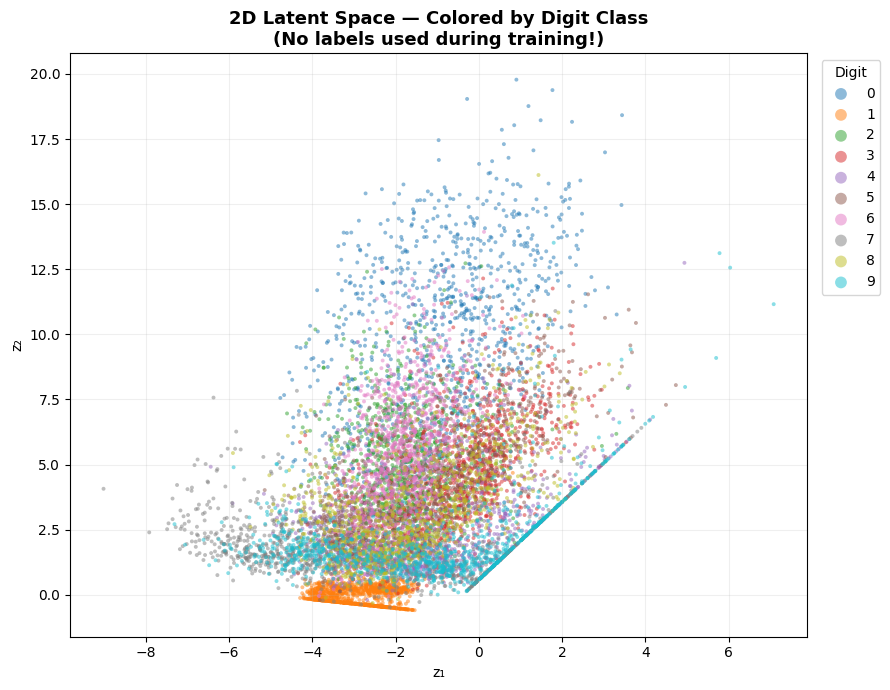

Even without labels, similar digits cluster together in the latent space!


In [56]:
def get_embeddings(model, loader, max_samples=10000):
    """Extract all latent vectors and labels from a dataset."""
    model.eval()
    all_z, all_labels = [], []
    count = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            imgs = imgs.flatten(start_dim=1)
            z = model.encode(imgs)
            z = z.unsqueeze(0).cpu().numpy()
            all_z.append(z)
            labels = labels.unsqueeze(0)
            all_labels.append(labels.numpy())
            count += imgs.size(0)
            if count >= max_samples:
                break
    
    return np.concatenate(all_z)[:max_samples], np.concatenate(all_labels)[:max_samples]


z_2d, labels_2d = get_embeddings(ae, train_loader)

# Colormap for 10 digit classes
cmap = plt.cm.get_cmap('tab10', 10)

fig, ax = plt.subplots(figsize=(9, 7))
for digit in range(10):
    mask = labels_2d == digit
    ax.scatter(z_2d[mask, 0], z_2d[mask, 1],
               c=[cmap(digit)], label=str(digit),
               alpha=0.5, s=8, edgecolors='none')

ax.set_title('2D Latent Space — Colored by Digit Class\n(No labels used during training!)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
legend = ax.legend(title='Digit', bbox_to_anchor=(1.01, 1), loc='upper left',
                   markerscale=3, fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Even without labels, similar digits cluster together in the latent space!")

### 5.1 Latent Space Interpolation

One of the most striking properties of a well-trained autoencoder is **smooth interpolation**: moving in a straight line between two points in latent space produces a smooth, semantically meaningful transition in image space.

This reveals that the latent space is **continuous and structured** — it's not just a lookup table.

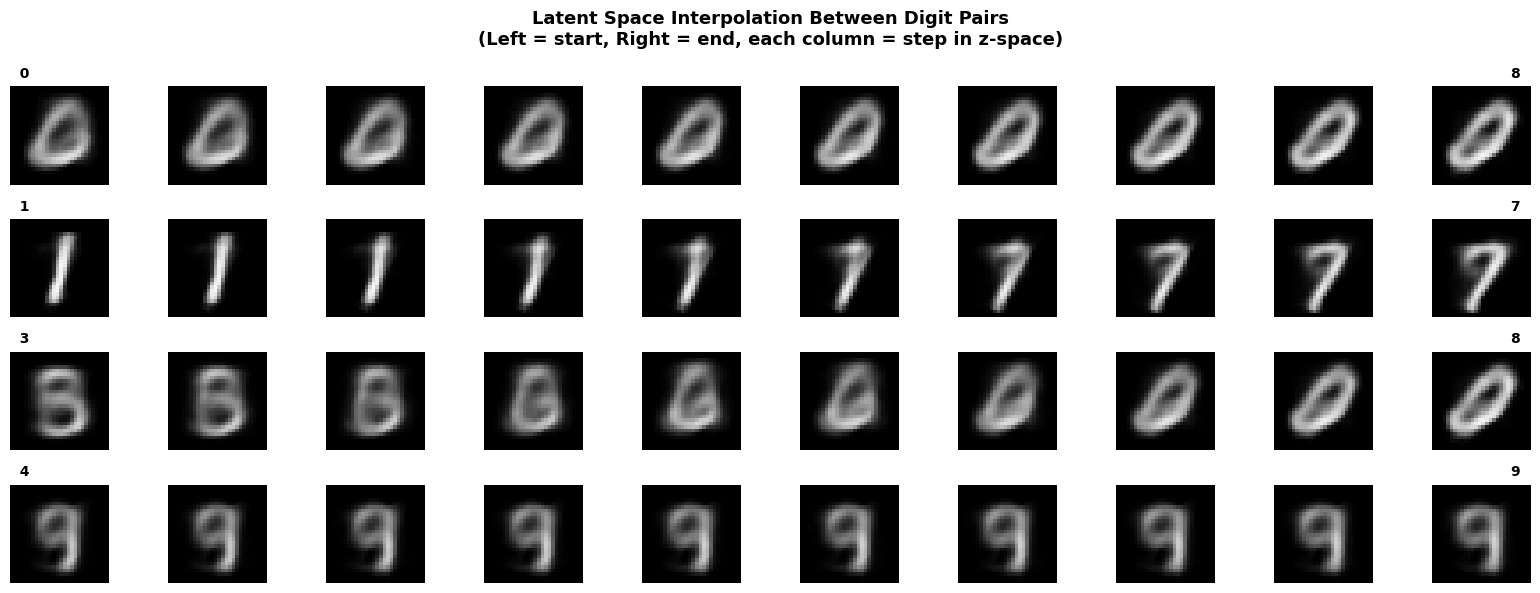

In [58]:
def interpolate_digits(model, dataset, digit_a, digit_b, n_steps=10):
    """Interpolate between two digit classes in latent space."""
    model.eval()

    def get_sample(cls):
        idx = next(i for i, (_, y) in enumerate(dataset) if y == cls)
        return dataset[idx][0].unsqueeze(0).to(device)

    img_a = get_sample(digit_a)
    img_b = get_sample(digit_b)

    with torch.no_grad():
        img_a = img_a.flatten(start_dim=1)
        img_b = img_b.flatten(start_dim=1)
        z_a = model.encode(img_a)
        z_b = model.encode(img_b)

        alphas = np.linspace(0, 1, n_steps)
        frames = []
        for alpha in alphas:
            z_interp = (1 - alpha) * z_a + alpha * z_b
            recon = model.decode(z_interp).cpu().squeeze().numpy()
            frames.append(recon.reshape(28,28))

    return frames, img_a.cpu().squeeze().numpy().reshape(28,28), img_b.cpu().squeeze().numpy().reshape(28,28)


pairs = [(0, 8), (1, 7), (3, 8), (4, 9)]
n_steps = 10

fig, axes = plt.subplots(len(pairs), n_steps, figsize=(16, 6))

for row, (da, db) in enumerate(pairs):
    frames, img_a, img_b = interpolate_digits(ae, test_dataset, da, db, n_steps)
    for col, frame in enumerate(frames):
        axes[row, col].imshow(frame, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'  {da}', fontsize=10, fontweight='bold', loc='left')
        elif col == n_steps - 1:
            axes[row, col].set_title(f'{db}  ', fontsize=10, fontweight='bold', loc='right')

fig.suptitle('Latent Space Interpolation Between Digit Pairs\n'
             '(Left = start, Right = end, each column = step in z-space)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()